# Dispersive detuning Purcell

It is typical to see the Purcell detuning improvement by sweeping the qubit frequency for otherwise fixed coupling to the readout resonator. 

A more appropriate analysis may be to vary the qubit frequency while simultaneously updating the capacitive coupling to maintain a fixed dispersive shift. 

Keep $E_/E_C$ fixed through out. Keep readout resonator fixed at 7 GHz.

Output $\kappa/2\pi=1$ MHz, Desired $2\chi=1$ MHz. 

In [149]:
readoutFrequency = 7 * 1e9
kappa = 1e6
dispersiveShift = 1e6

In [150]:
import numpy as np
import skrf as rf

rf.stylely()

import matplotlib.pyplot as plt
import scqubits as scq

In [151]:
from numpy import pi
from scipy.constants import *

Phi0 = value("mag. flux quantum")


def cap_energy(capacitance: float) -> float:
    return e**2 / (2 * capacitance) / h


def ind_energy(inductance: float) -> float:
    return (Phi0 / (2 * pi)) ** 2 * 1 / inductance / h


def jj_energy_ind(inductance: float) -> float:
    return ind_energy(inductance)


def jj_energy_cc(critical_current: float) -> float:
    return (Phi0 / (2 * pi)) * critical_current / h


def Ec_to_cap(Ec: float) -> float:
    return e**2 / (2 * Ec * h)


def Ej_to_ind(Ej: float) -> float:
    return (Phi0 / (2 * pi)) ** 2 * 1 / Ej / h


def Ic_to_Lj(Ic):
    return (Phi0 / (2 * pi)) / Ic


In [152]:
from skrf_cqed.analysis.admittance_T1 import differential_admittance, purcell_t1
from skrf_cqed.analysis.reductions import line_loading
from skrf_cqed.elements.tline_wrapper import DefinedBetaZ0

In [153]:
freq = rf.Frequency(1, 10, 50001, "ghz")

epsRel = 5.567
vph = rf.constants.c / np.sqrt(epsRel)
tl_media = DefinedBetaZ0(frequency=freq, z0=50, vph=vph * (1.0 + 1e-7 * 1j))

Adjust $C_{ext}$ to set the resaonator linewidth.

In [154]:
C_ext = 6.82 * 1e-15

cap_ext = tl_media.capacitor(C_ext, name="cap_kext")

res_halfwave = tl_media.line_electrical_length(
    180, unit="deg", f0= readoutFrequency, name="halfwave"
)

port = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port1")
port2 = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port2")

gnd = rf.circuit.Circuit.Ground(frequency=freq, name="gnd")

cnx = [
    [(port, 0), (cap_ext, 1)],
    [(cap_ext, 0), (res_halfwave, 0)],
    [(res_halfwave, 1), (port2, 0)],
]

cir_res = rf.circuit.Circuit(
    cnx,
    dynamic_networks=[res_halfwave],
    name="resonator",
)
ntwk_res = cir_res.network


Adjust for loading

In [155]:

# If freq is sparse, worth recomputing network at target frequency
temp_freq = rf.Frequency(readoutFrequency, readoutFrequency, 1, unit="Hz")
temp_media = DefinedBetaZ0(frequency=temp_freq, z0=50, vph=vph)

temp_cap = temp_media.capacitor(C_ext, name="cap")
gnd = rf.circuit.Circuit.Ground(frequency=temp_freq, name="gnd")

ntwk_capGnd = rf.network.connect(temp_cap, 0, gnd, 0)

extLoading = line_loading(ntwk_capGnd, z0=50.0)

res_halfwave = tl_media.line_electrical_length(
    180 - extLoading, unit="deg", f0=readoutFrequency, name="halfwave"
)

cir_res.update_networks(networks=[res_halfwave], inplace=True)

ntwk_res = cir_res.network

open = rf.circuit.Circuit.Open(frequency=freq, name="open")

# just for plotting on its own
ntwk_resExt2 = rf.network.connect(ntwk_res, 1, open, 0)

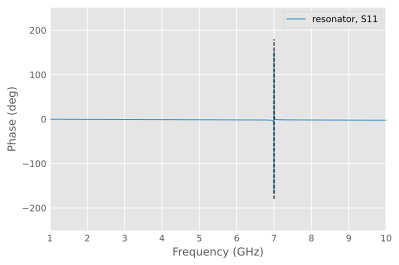

In [156]:
ntwk_resExt2.plot_s_deg()
plt.vlines(readoutFrequency, -180, 180, color="k", linestyle="--", label="f0")

Get linewidth

In [157]:
from resonator_tools.circuit import reflection_port

readout_fit = reflection_port(freq.f, ntwk_resExt2.s[:, 0, 0])

readout_fit.autofit(fcrop=[6e9, 8e9])
# readout_fit.autofit()
# readout_fit.plotall()

import pandas as pd  # noqa: I001

display(pd.DataFrame([readout_fit.fitresults]).map(lambda x: f"{x:.2e}"))

kappa = 2 * np.pi * readout_fit.fitresults["fr"] / readout_fit.fitresults["Qc"]

print(f"fr = {readout_fit.fitresults['fr'] * 1e-9:.3f} GHz")
print(f"kappa/2π {kappa / (2 * np.pi) * 1e-6:.3f} MHz")

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
real = readout_fit.z_data_raw.real
imag = readout_fit.z_data_raw.imag
real2 = readout_fit.z_data_sim.real
imag2 = readout_fit.z_data_sim.imag

axs[0].plot(real, imag, ".", label="rawdata")
axs[0].plot(real2, imag2, label="fit")
axs[0].set_xlabel("Re(S11)")
axs[0].set_ylabel("Im(S11)")

axs[1].plot(
    readout_fit.f_data * 1e-9, np.absolute(readout_fit.z_data_raw), ".", label="rawdata"
)
axs[1].plot(readout_fit.f_data * 1e-9, np.absolute(readout_fit.z_data_sim), label="fit")
axs[1].set_xlabel("f (GHz)")
axs[1].set_ylabel("|S11|")
axs[1].legend()

axs[2].plot(
    readout_fit.f_data * 1e-9, np.angle(readout_fit.z_data_raw), ".", label="rawdata"
)
axs[2].plot(readout_fit.f_data * 1e-9, np.angle(readout_fit.z_data_sim), label="fit")
axs[2].set_xlabel("f (GHz)")
axs[2].set_ylabel("arg(|S11|)")

fig.suptitle(
    f"S11 fres = {readout_fit.fitresults['fr'] * 1e-9:.3f} GHz, kappa/2π = {kappa / (2 * np.pi) * 1e-6:.3f} MHz"
)
plt.tight_layout()


 improvement from the last ten iterations.
 c:\Users\zlp\AppData\Local\miniforge3\envs\scq\Lib\site-packages\resonator_tools\circlefit.py: 379RuntimeWarning: Number of calls to function has reached maxfev = 400.
 c:\Users\zlp\AppData\Local\miniforge3\envs\scq\Lib\site-packages\resonator_tools\circlefit.py: 441

,Qi,Qc,Ql,fr,theta0,Ql_err,Qc_err,fr_err,chi_square,Qi_err
0,5.03e+06,7.00e+03,6.99e+03,7.00e+09,2.69e-07,3.87e+00,2.75e+00,1.97e+02,1.34e-06,1.42e+06


fr = 7.000 GHz
kappa/2π 1.001 MHz


To achieve $\kappa/2\pi=$ 1 MHz, $C_{ext}=$ 6.82 fF. 

## Determing C qr for $2\chi$

Qubit frequency will range from 2 to 6 GHz. 

In [158]:
def Ycap(C, f):
    return 1j * 2 * np.pi * f * C


def Yind(L, f):
    return 1 / (1j * 2 * np.pi * f * L)


def Zcap(C, f):
    return 1 / (1j * 2 * np.pi * f * C)


def Zind(L, f):
    return 1j * 2 * np.pi * f * L


def Yparallel(Y1, Y2):
    return Y1 + Y2


def Yseries(Y1, Y2):
    return 1 / (1 / Y1 + 1 / Y2)


def Zparallel(Z1, Z2):
    return 1 / (1 / Z1 + 1 / Z2)


def Zseries(Z1, Z2):
    return Z1 + Z2

In [159]:
# lumped element equivalent LC for a half-wave resonator
def resonator_half(freq, Zo):
    C = 1 / (4 * freq * Zo)
    L = 1 / (4 * np.pi**2 * freq**2 * C)
    return (L, C)

def grounded_transmon_loading(cmatrix, jjinductance, freq, mapping=None):
    if mapping is not None:
        raise NotImplementedError("Mapping not implemented yet")
    else:
        Cqg = cmatrix["Cqg"]
        Crg = cmatrix["Crg"]
        Crq = cmatrix["Crq"]
        Ljj = jjinductance

    Zqubit = Zparallel(Zind(Ljj, freq), Zcap(Cqg, freq))
    Zcq = Zseries(Zqubit, Zcap(Crq, freq))
    if Crg != 0:
        Ztotal = Zparallel(Zcap(Crg, freq), Zcq)
    else:
        Ztotal = Zcq

    return Ztotal

class QubitReadout:
    def __init__(self, qubitParams, resFreq, cap):
        self.Lq = qubitParams["Lq"]
        self.Cq = qubitParams["Cq"]

        self.resFreq = resFreq
        self.cap = cap

        self._generateCircuit()

    def _getResonatorLC(self, f_r, cap_qr):
        # Zc = 1 / (2 * np.pi * 1j * f_r * cap_qr)
        Zc = grounded_transmon_loading(
            {"Cqg": self.Cq - cap_qr, "Crg": 0e-15, "Crq": cap_qr}, self.Lq, f_r
        )
        gamma = (Zc - 50) / (Zc + 50)
        angleAdjust = -1 / 2 * np.arctan2(np.imag(gamma), np.real(gamma))
        # print(np.rad2deg(angleAdjust))

        self.omega_new = f_r * 180 / (180 - np.rad2deg(angleAdjust))

        return resonator_half(self.omega_new, 50)

    def _generateCircuit(self):
        Lr, Cr = self._getResonatorLC(self.resFreq, self.cap)

        self.capacitance_dict = {"Q": self.Cq - self.cap, "R": Cr, "QR": self.cap}
        inductance_dict = {"Q": self.Lq, "R": Lr}

        Ec_dict = {
            key: cap_energy(cap) / giga for (key, cap) in self.capacitance_dict.items()
        }
        El_dict = {
            key: ind_energy(ind) / giga for (key, ind) in inductance_dict.items()
        }

        yaml = f"""
        branches:
        - ["JJ", 0, 1, {El_dict["Q"]}, {Ec_dict["Q"]}]
        # - ["L", 0, 1, {El_dict["Q"]}] 
        # - ["C", 0, 1, {Ec_dict["Q"]}]
        - ["L", 0, 2, {El_dict["R"]}]
        - ["C", 0, 2, {Ec_dict["R"]}]
        - ["C", 1, 2, {Ec_dict["QR"]}]
        """

        self.circuit = scq.Circuit(yaml, from_file=False, ext_basis="harmonic")
        self.circuit.configure(transformation_matrix=np.identity(2))

        self.circuit.cutoff_n_1 = 40
        # self.circuit.cutoff_ext_1 = 40
        self.circuit.cutoff_ext_2 = 40

        self.circuit.configure(
            system_hierarchy=[[1], [2]], subsystem_trunc_dims=[20, 20]
        )

    def solve(self):
        self.circuit.update()
        self.hspace = self.circuit.hilbert_space

        self.hspace.generate_lookup(ordering="BE", BEs_count=20)

        # evalsA = self.hspace.eigenvals(evals_count=20)
        self.qubitFreq = self.hspace.energy_by_bare_index((1, 0), subtract_ground=True)
        self.resFreq = self.hspace.energy_by_bare_index((0, 1), subtract_ground=True)

        self.zzFreq = (
            self.hspace.energy_by_bare_index((1, 1), subtract_ground=True)
            - self.qubitFreq
            - self.resFreq
        )
        self.qubitAnharm = (
            self.hspace.energy_by_bare_index((2, 0), subtract_ground=True)
            - 2 * self.qubitFreq
        )
        self.resAnharm = (
            self.hspace.energy_by_bare_index((0, 2), subtract_ground=True)
            - 2 * self.resFreq
        )

In [160]:
import scipy as sp


def find_EJ_EC_alt(E01: float, EjEcRatio: float, ng=0, ncut=30):
    """Finds the EJ and EC values given a qubit splitting `E01` and Ej/Ec ratio."""
    
    tmon = scq.Transmon(EJ=10.0, EC=0.1, ng=ng, ncut=ncut)
    start_EJ_EC = np.array([tmon.EJ, tmon.EC])

    def cost_func(EJ_EC):
        EJ, EC = EJ_EC
        tmon.EJ = EJ
        tmon.EC = EC
        energies = tmon.eigenvals(evals_count=3)
        computed_E01 = energies[1] - energies[0]
        
        cost = (E01 - computed_E01) ** 2
        cost += (EjEcRatio - EJ / EC) ** 2
        return cost

    return sp.optimize.minimize(cost_func, start_EJ_EC).x


In [161]:
def find_Cqr(E01, EjEcRatio, dispersiveShift, resFreq, min_03_detuning=0.1):
    Ej, Ec = find_EJ_EC_alt(E01 * 1e-9, EjEcRatio)

    transmon = scq.Transmon(EJ=Ej, EC=Ec, ng=0.0, ncut=30)
    transmon_energies = transmon.eigenvals(evals_count=12)
    transition_03 = transmon_energies[3] - transmon_energies[0]
    transition_03_detuning = abs(transition_03 - resFreq / giga)
    
    # print(f"Qubit Frequency: {transmon_energies[1] - transmon_energies[0]:.3f} GHz")
    # print(f"0-3 Transition: {transition_03:.3f} GHz")
    # print(f"Detuning: {transition_03_detuning:.3f} GHz")

    if transition_03_detuning < min_03_detuning:
        raise ValueError(
            f"Readout is too close to the 0-3 transition: "
            f"f03={transition_03:.3f} GHz, "
            f"freadout={resFreq / giga:.3f} GHz, "
            f"detuning={transition_03_detuning:.3f} GHz"
        )

    Cq = Ec_to_cap(Ec * giga)
    qubit_params = {"Lq": Ej_to_ind(Ej * giga), "Cq": Cq}

    # Estimate a useful search region from one reference calculation.
    reference_cap_fF = 11.0
    reference_qr = QubitReadout(
        qubit_params,
        resFreq=resFreq,
        cap=reference_cap_fF * femto,
    )
    reference_qr.solve()
    reference_shift_hz = reference_qr.zzFreq * giga

    if reference_shift_hz * dispersiveShift > 0 and abs(reference_shift_hz) > 1:
        guess_cap_fF = reference_cap_fF * np.sqrt(
            abs(dispersiveShift / reference_shift_hz)
        )
    else:
        guess_cap_fF = reference_cap_fF

    max_cap_fF = 0.9 * Cq / femto
    guess_cap_fF = np.clip(guess_cap_fF, 0.001, max_cap_fF)

    def cost_func(cap_fF):
        cap = float(cap_fF) * femto

        if cap >= Cq:
            return 1e30

        qr = QubitReadout(qubit_params, resFreq=resFreq, cap=cap)
        qr.solve()

        computed_shift_hz = qr.zzFreq * giga
        return ((computed_shift_hz - dispersiveShift) / mega) ** 2

    lower_fF = max(0.001, 0.5 * guess_cap_fF)
    upper_fF = min(max_cap_fF, 2.0 * guess_cap_fF)

    result = sp.optimize.minimize_scalar(
        cost_func,
        bounds=(lower_fF, upper_fF),
        method="bounded",
        options={"xatol": 1e-4},
    )

    if not result.success:
        raise RuntimeError(result.message)

    return result.x * femto

In [162]:
qubit_freqs = np.concatenate([np.linspace(2.0e9, 6.0e9, 51), np.linspace(8.0e9, 10.0e9, 25)])
qubit_freqs = np.linspace(2.0e9, 10.0e9, 101)

Cqr_list = []
for f in qubit_freqs:
    try:
        Cqr = find_Cqr(f, 70.0, -1 * 1e6, 7.5e9, min_03_detuning=0.5)
    except ValueError as error:
        print(f"Skipping {f / giga:.3f} GHz: {error}")
        Cqr = np.nan
    Cqr_list.append(Cqr)

Skipping 2.480 GHz: Readout is too close to the 0-3 transition: f03=7.060 GHz, freadout=7.500 GHz, detuning=0.440 GHz
Skipping 2.560 GHz: Readout is too close to the 0-3 transition: f03=7.287 GHz, freadout=7.500 GHz, detuning=0.213 GHz
Skipping 2.640 GHz: Readout is too close to the 0-3 transition: f03=7.515 GHz, freadout=7.500 GHz, detuning=0.015 GHz
Skipping 2.720 GHz: Readout is too close to the 0-3 transition: f03=7.743 GHz, freadout=7.500 GHz, detuning=0.243 GHz
Skipping 2.800 GHz: Readout is too close to the 0-3 transition: f03=7.971 GHz, freadout=7.500 GHz, detuning=0.471 GHz


Text(0, 0.5, 'Coupling Capacitance Cqr (fF)')

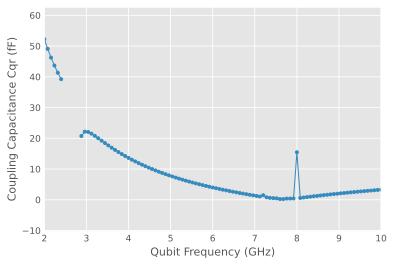

In [163]:
plt.plot(qubit_freqs * 1e-9, np.array(Cqr_list) * 1e15, marker="o")
plt.xlabel("Qubit Frequency (GHz)")
plt.ylabel("Coupling Capacitance Cqr (fF)")

In [164]:
zz_list = []
Lq_list = []
Cq_list = []

for i in range(len(qubit_freqs)):

    qubit_freq = qubit_freqs[i]
    Cqr = Cqr_list[i]

    if not np.isfinite(Cqr):
        zz_list.append(np.nan)
        Lq_list.append(np.nan)
        Cq_list.append(np.nan)
        continue

    Ej, Ec = find_EJ_EC_alt(qubit_freq * 1e-9, 70.0)
    Lq_list.append(Ej_to_ind(Ej * giga))
    Cq_list.append(Ec_to_cap(Ec * giga))

    q0 = QubitReadout(
        qubitParams={
            "Lq": ind_energy(Ej * giga),
            "Cq": cap_energy(Ec * giga) - 0.0 * femto,
        },
        resFreq=7.5e9 - 0e6,
        cap=Cqr,
    )

    q0.solve()
    # print(f"Qubit Frequency: {q0.qubitFreq:.3f} GHz target:  GHz")
    # print(f"Resonator Frequency: {q0.resFreq:.3f} GHz target:  GHz")
    # print(f"ZZ Frequency: {q0.zzFreq * 1e3:.2f} MHz")
    perError = abs(q0.zzFreq * giga - (-1 * 1e6)) / 1e6 * 100
    
    if perError > 5:
        Cqr_list[i] = np.nan
        zz_list.append(np.nan)
    else:
        zz_list.append(q0.zzFreq)

# print(q0.capacitance_dict)
# print(f" omega_target: {q0.omega_new / 1e9:.3f} GHz")
# print(f"Purcell Rate: {1/(q0.Gp*10**(-2))*1e6:.2e} Hz")

Get interpolated Cq for the range 2 to 10 GHz

In [165]:
from scipy.interpolate import interp1d

Cq_full_list = []
fq_full_list = np.linspace(2e9, 10e9, 100)
for i, fq in enumerate(fq_full_list):
    Ej, Ec = find_EJ_EC_alt(fq * 1e-9, 70.0)
    Cq_full_list.append(Ec_to_cap(Ec * giga))

Cq_of_freq = interp1d(
    fq_full_list,
    np.asarray(Cq_full_list),
    kind="cubic",
    bounds_error=False,
    fill_value=np.nan,
)


(-1.5, 0.0)

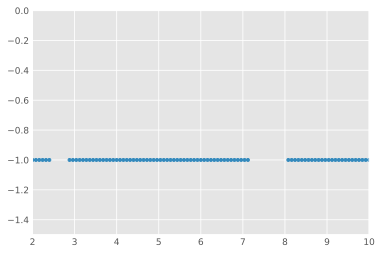

In [166]:
plt.plot(qubit_freqs * 1e-9, np.array(zz_list)*1e3,  marker="o")
plt.ylim([-1.5, 0.])

# plt.plot(qubit_freqs * 1e-9, 0.15*np.array(Cqr_list) * 1e15, marker="o")

For each freq capacitacne pair, modify the network values

In [167]:
len(Cq_list), len(Lq_list), len(zz_list)

(101, 101, 101)

In [168]:
T1_list = []

for i in range(len(qubit_freqs)):
        
    if not np.isnan(Cqr_list[i]):    
        temp_freq = rf.Frequency(qubit_freqs[i], qubit_freqs[i], 1, unit="Hz")
        temp_media = DefinedBetaZ0(frequency=temp_freq, z0=50, vph=vph)
        
        Zc = grounded_transmon_loading(
            {"Cqg": Cq_list[i] - Cqr_list[i], "Crg": 0e-15, "Crq": Cqr_list[i]}, Lq_list[i], readoutFrequency
        )
        gamma = (Zc - 50) / (Zc + 50)
        qubitLoading = -1 / 2 * np.arctan2(np.imag(gamma), np.real(gamma))
        
        res_halfwave = temp_media.line_electrical_length(
            180 - extLoading - qubitLoading, unit="deg", f0=readoutFrequency, name="halfwave")
        
        capQR = temp_media.capacitor(Cqr_list[i], name="capQR")
        capExt = temp_media.capacitor(C_ext, name="capExt")
        
        network = capQR ** res_halfwave ** capExt
        networkPurcell = network.subnetwork([0,])
        
        # get the single frequency value
        T1_list.append(purcell_t1(networkPurcell, Cq_list[i])[0])
    else:
        T1_list.append(np.nan)

Text(0.5, 1.0, 'Purcell T1 for fixed $2\\chi$, $\\kappa$')

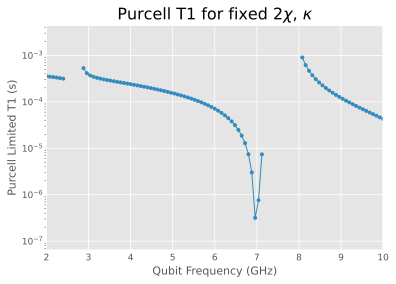

In [169]:
plt.semilogy(qubit_freqs * 1e-9, np.array(T1_list), marker="o")

plt.xlabel("Qubit Frequency (GHz)")
plt.ylabel("Purcell Limited T1 (s)")
plt.title(r"Purcell T1 for fixed $2\chi$, $\kappa$")

For comparison use the fixed Cqr from 4 GHz qubit

In [170]:
id_4 = np.argmin(np.abs(np.array(qubit_freqs) - 4e9))

Zc = grounded_transmon_loading(
    {"Cqg": Cq_list[id_4] - Cqr_list[id_4], "Crg": 0e-15, "Crq": Cqr_list[id_4]}, Lq_list[id_4], readoutFrequency
)
gamma = (Zc - 50) / (Zc + 50)
qubitLoading = -1 / 2 * np.arctan2(np.imag(gamma), np.real(gamma))

res_halfwave = tl_media.line_electrical_length(
    180 - extLoading - qubitLoading, unit="deg", f0=readoutFrequency, name="halfwave")

capQR = tl_media.capacitor(Cqr_list[id_4], name="capQR")
capExt = tl_media.capacitor(C_ext, name="capExt")

network = capQR ** res_halfwave ** capExt
networkPurcell = network.subnetwork([0,])

T1compare = purcell_t1(networkPurcell, Cq_list[id_4])

# scale by the appropriate Cshunt values
T1compare_scaled = T1compare * Cq_list[id_4] / Cq_of_freq(freq.f)

In [171]:
def nan_blocks(values):
    values = np.asarray(values)
    nan_mask = np.isnan(values)

    starts = np.flatnonzero(nan_mask & ~np.r_[False, nan_mask[:-1]])
    ends = np.flatnonzero(nan_mask & ~np.r_[nan_mask[1:], False])

    return list(zip(starts, ends))

In [172]:
exclusion_blocks = nan_blocks(Cqr_list)

In [173]:
exclusion_blocks

[(np.int64(6), np.int64(10)), (np.int64(65), np.int64(75))]

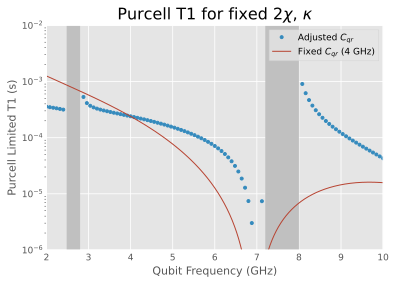

In [215]:
fig,ax = plt.subplots()

ax.semilogy(qubit_freqs * 1e-9, np.array(T1_list), "o", label="Adjusted $C_{qr}$")

# plt.semilogy(freq.f*1e-9, T1compare, linestyle="--", label=r"Fixed $C_{qr}$")

ax.semilogy(freq.f * 1e-9, T1compare_scaled, label=r"Fixed $C_{qr}$ (4 GHz)")

import matplotlib.patches as patches

# rect = patches.Rectangle((6, 1e-6), 2, 1e-2, facecolor='lightgray', label="0-1 exclusion")
# ax.add_patch(rect)

for i in range(len(exclusion_blocks)):
    freqs = np.array([qubit_freqs[exclusion_blocks[i][0]], qubit_freqs[exclusion_blocks[i][1]]])
    rect = patches.Rectangle((freqs[0] * 1e-9, 1e-6), (freqs[1] - freqs[0]) * 1e-9, 1e-2, facecolor='silver') #, label=f"{i}-{i+1} exclusion")
    ax.add_patch(rect)
# freqs03 = np.array([qubit_freqs[exclusion_blocks[0][0]], qubit_freqs[exclusion_blocks[0][1]]])
# rect3 = patches.Rectangle((freqs03[0] * 1e-9, 1e-6), (freqs03[1] - freqs03[0]) * 1e-9, 1e-2, facecolor='silver', label="0-3 exclusion")
# ax.add_patch(rect3)

# plt.semilogy(freq.f * 1e-9, 1e-23*(freq.f - 7e9) ** 2)

# fit = [0.75e-13 * np.power(abs(f - 6.9e9), 1.0) for f in freq.f]
# plt.semilogy(freq.f * 1e-9, fit)


ax.set_xlabel("Qubit Frequency (GHz)")
ax.set_ylabel("Purcell Limited T1 (s)")
ax.set_title(r"Purcell T1 for fixed $2\chi$, $\kappa$")
# plt.xlim([2, 6])
ax.set_ylim([1e-6, 1e-2])
ax.legend()

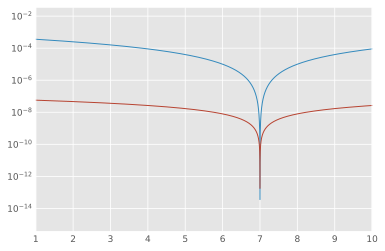

In [205]:
plt.semilogy(freq.f * 1e-9, 1e-23 / (freq.f - 7e9)**-2)
plt.semilogy(freq.f * 1e-9, fit)

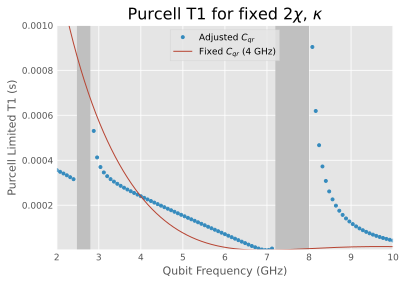

In [179]:
fig, ax = plt.subplots()

ax.plot(qubit_freqs * 1e-9, np.array(T1_list), "o", label="Adjusted $C_{qr}$")

# plt.semilogy(freq.f*1e-9, T1compare, linestyle="--", label=r"Fixed $C_{qr}$")

ax.plot(freq.f * 1e-9, T1compare_scaled, label=r"Fixed $C_{qr}$ (4 GHz)")

import matplotlib.patches as patches

# rect = patches.Rectangle((6, 1e-6), 2, 1e-2, facecolor='lightgray', label="0-1 exclusion")
# ax.add_patch(rect)

for i in range(len(exclusion_blocks)):
    freqs = np.array(
        [qubit_freqs[exclusion_blocks[i][0]], qubit_freqs[exclusion_blocks[i][1]]]
    )
    rect = patches.Rectangle(
        (freqs[0] * 1e-9, 1e-6), (freqs[1] - freqs[0]) * 1e-9, 1e-2, facecolor="silver"
    )  # , label=f"{i}-{i+1} exclusion")
    ax.add_patch(rect)
# freqs03 = np.array([qubit_freqs[exclusion_blocks[0][0]], qubit_freqs[exclusion_blocks[0][1]]])
# rect3 = patches.Rectangle((freqs03[0] * 1e-9, 1e-6), (freqs03[1] - freqs03[0]) * 1e-9, 1e-2, facecolor='silver', label="0-3 exclusion")
# ax.add_patch(rect3)


ax.set_xlabel("Qubit Frequency (GHz)")
ax.set_ylabel("Purcell Limited T1 (s)")
ax.set_title(r"Purcell T1 for fixed $2\chi$, $\kappa$")
# plt.xlim([2, 6])
ax.set_ylim([1e-6, 1e-3])
ax.legend()
